<h1>Task 3: Model Creation & Evaluation</h1>

In [1]:
import pandas as pd
import numpy as np
from sklearn_functions import RandomForestClassifier, StandardScaler, train_test_split, accuracy_score, precision_score, recall_score, f1_score


<h2>Model Training</h2>

In [2]:
df = pd.read_csv("cardio_cleaned.csv")
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,age_group,ap_hi_z,ap_lo_z,bmi,ap_hi_log,ap_lo_log,bmi_log
0,2,168,62.0,110,80,1,1,0,0,1,0,50.0,2,-0.829405,-0.166623,21.967120,4.709530,4.394449,3.134064
1,1,156,85.0,140,90,3,1,0,0,1,1,55.0,3,0.526506,0.603754,34.927679,4.948760,4.510860,3.581508
2,1,165,64.0,130,70,3,1,0,0,0,1,51.0,3,0.074536,-0.937000,23.507805,4.875197,4.262680,3.198992
3,2,169,82.0,150,100,1,1,0,0,1,1,48.0,2,0.978476,1.374130,28.710479,5.017280,4.615121,3.391500
4,1,156,56.0,100,60,1,1,0,0,0,0,47.0,2,-1.281375,-1.707376,23.011177,4.615121,4.219834,3.178519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69944,2,168,76.0,120,80,1,1,1,0,1,0,52.0,3,-0.377434,-0.166623,26.927438,4.795791,4.394449,3.329610
69945,1,158,126.0,140,90,2,2,0,0,1,1,61.0,3,0.526506,0.603754,39.661304,4.948760,4.510860,3.779409
69946,2,183,105.0,180,90,3,1,0,1,0,1,52.0,3,2.334387,0.603754,31.353579,5.178214,4.510860,3.476725
69947,1,163,72.0,135,80,1,2,0,0,0,1,61.0,3,0.300521,-0.166623,27.099251,4.912655,4.394449,3.335743


In [3]:
target = 'cardio'
features = [col for col in df.columns if col != target]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features].values, df[target].values, test_size=0.2, random_state=27
)

In [5]:

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    max_features=2,
    random_state=42
)


In [6]:
rf_model.fit(X_train, y_train,)

In [7]:
y_pred = rf_model.predict(X_test)

In [8]:
acu = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [9]:
print(f"Accuracy : {acu:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1 Score : {f1:.3f}")

Accuracy : 0.704
Precision: 0.777
Recall   : 0.572
F1 Score : 0.659


<h2>Model Evaluation</h2>

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [11]:
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

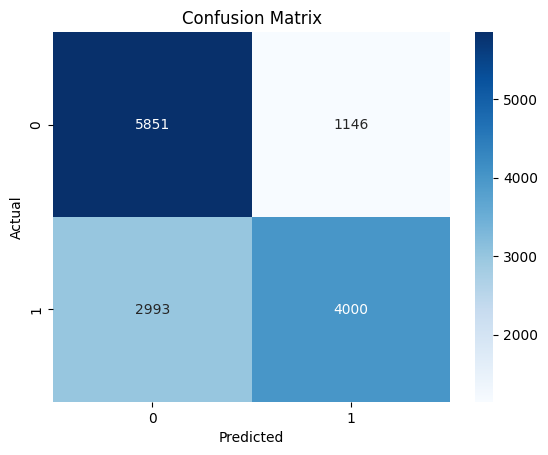

In [82]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
# --- Classification Report ---
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.84      0.74      6997
           1       0.78      0.57      0.66      6993

    accuracy                           0.70     13990
   macro avg       0.72      0.70      0.70     13990
weighted avg       0.72      0.70      0.70     13990



In [13]:

ap_hi_idx = features.index('ap_hi')
ap_lo_idx = features.index('ap_lo')

scaler_hi = StandardScaler().fit(X_train[:, ap_hi_idx].reshape(-1, 1))
scaler_lo = StandardScaler().fit(X_train[:, ap_lo_idx].reshape(-1, 1))

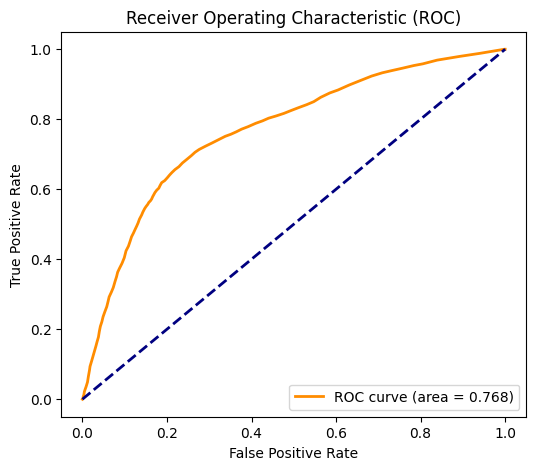

In [85]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

<h2>Save model on disk</h2>

In [14]:
import pickle

bundle = {
    "model": rf_model,
    "columns": features,
    "scaler_hi": scaler_hi,
    "scaler_lo": scaler_lo
}

with open("cardio_model.pkl", "wb") as f:
    pickle.dump(bundle, f)
